In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

dataset = "chethuhn/network-intrusion-dataset"

# List all file names in the dataset
files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
]

dfs = []
for file in files:
    temp_df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        dataset,
        file,
    )
    temp_df["source_file"] = file
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

# Fix encoding artifacts in label names
df[' Label'] = df[' Label'].str.replace('\ufffd', '-', regex=False)

# First look
print(df.shape)
print(df.head())
print(df.columns.tolist())



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/9v/yy_7q52d28z1cvhmb44hdph40000gn/T/ipykernel_73716/1639221939.py:24: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  temp_df = kagglehub.load_dataset(
/var/folders/9v/yy_7q52d28z1cvhmb44hdph40000gn/T/ipykernel_73716/1639221939.py:24: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  temp_df = kagglehub.load_dataset(
/var/folders/9v/yy_7q52d28z1cvhmb44hdph40000gn/T/ipykernel_73716/1639221939.py:24: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  temp_df = kagglehub.load_dataset(
/var

(2830743, 80)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              49188               4                   2   
1              49188               1                   2   
2              49188               1                   2   
3              49188               1                   2   
4              49486               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        0                           12   
2                        0                           12   
3                        0                           12   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             0                       6   
2                             0                       6   
3                             0   

Explore the Label Column

In [4]:
# Check what attack types exist and how many of each
print(df[' Label'].value_counts())
print("\nClass proportions:")
print(df[' Label'].value_counts(normalize=True).round(3))


 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Class proportions:
 Label
BENIGN                        0.803
DoS Hulk                      0.082
PortScan                      0.056
DDoS                          0.045
DoS GoldenEye                 0.004
FTP-Patator                   0.003
SSH-Patator                   0.002
DoS slowloris                 0.002
DoS Slowhttptest              0.002
Bot                           0.001
Web Attack

Data Quality Check

In [5]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Check infinite values
print("\nInfinite values per column:")
inf_counts = df.isin([np.inf, -np.inf]).sum()
print(inf_counts[inf_counts > 0])

# Basic stats on numeric columns
print("\nBasic statistics:")
df.describe()

Missing values per column:
Flow Bytes/s    1358
dtype: int64

Infinite values per column:
Flow Bytes/s       1509
 Flow Packets/s    2867
dtype: int64

Basic statistics:


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [6]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column median
df.fillna(df.median(numeric_only=True), inplace=True)

# Verify nothing remains
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining infinite values:", df.isin([np.inf, -np.inf]).sum().sum())

Remaining missing values: 0
Remaining infinite values: 0


Remove classes where there are too few samples to learn from

In [7]:
# Drop classes with too few samples to learn from
rare_classes = ['Heartbleed', 'Infiltration', 'Web Attack - Sql Injection']
df = df[~df[' Label'].isin(rare_classes)]

# Verify remaining classes
print(df[' Label'].value_counts())
print(f"\nTotal samples remaining: {df.shape[0]}")
print(f"Classes remaining: {df[' Label'].nunique()}")

 Label
BENIGN                      2273097
DoS Hulk                     231073
PortScan                     158930
DDoS                         128027
DoS GoldenEye                 10293
FTP-Patator                    7938
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1966
Web Attack - Brute Force       1507
Web Attack - XSS                652
Name: count, dtype: int64

Total samples remaining: 2830675
Classes remaining: 12


Visualize the Features

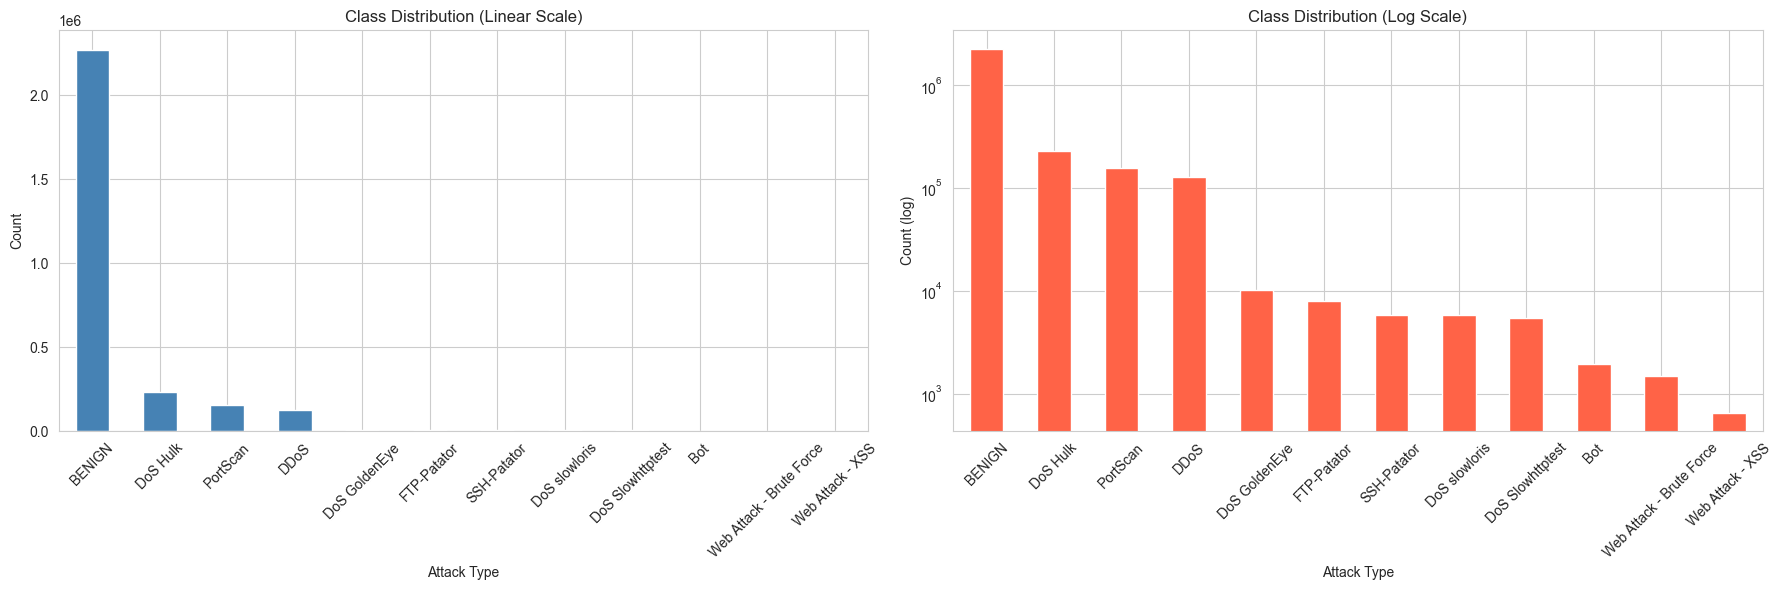

In [8]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

label_counts = df[' Label'].value_counts()

# Plot 1 — Linear scale
label_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution (Linear Scale)')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 — Log scale (shows rare classes clearly)
label_counts.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count (log)')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visuals/multiclass_distribution.png', dpi=150)
plt.show()

Feature Selection

In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode label for correlation analysis
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df[' Label'])

# Store class names for later
class_names = le.classes_
print("Class mapping:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

# Separate features and label
X = df.drop(columns=[' Label', 'Label_encoded', 'source_file'])
y = df['Label_encoded']

# Remove highly correlated features
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.90)]
X_reduced = X.drop(columns=to_drop)

print(f"\nFeatures dropped: {len(to_drop)}")
print(to_drop)
print(f"Features remaining: {X_reduced.shape[1]}")

Class mapping:
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: PortScan
  9: SSH-Patator
  10: Web Attack - Brute Force
  11: Web Attack - XSS

Features dropped: 31
[' Total Backward Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Std', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', ' Flow IAT Max', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Bwd IAT Min', 'Fwd Packets/s', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' SYN Flag Count', ' CWE Flag Count', ' ECE Flag Count', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segment Size', ' Fwd Header Length.1', 'Subflow Fwd Packets', ' Subflow Fwd Bytes', ' Subflow Bwd Packets', ' Subflow Bwd Bytes', ' Active Min', 'Idle Mean', ' Idle Max', ' Idle Min']
Features remaining: 47


Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("\nClass weights:")
for i, weight in class_weight_dict.items():
    print(f"  {class_names[i]}: {weight:.4f}")

Training samples: 2264540
Test samples:     566135

Class weights:
  BENIGN: 0.1038
  Bot: 119.9693
  DDoS: 1.8425
  DoS GoldenEye: 22.9186
  DoS Hulk: 1.0208
  DoS Slowhttptest: 42.8988
  DoS slowloris: 40.6969
  FTP-Patator: 29.7184
  PortScan: 1.4842
  SSH-Patator: 39.9982
  Web Attack - Brute Force: 156.4773
  Web Attack - XSS: 361.5166


Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"Training set mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training set std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete.
Training set mean (should be ~0): -0.0000
Training set std  (should be ~1): 0.9109


Random Forest Training and Predictions

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train Random Forest with class weights
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight=class_weight_dict)
rf.fit(X_train_scaled, y_train)

# Evaluate
y_pred = rf.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=class_names))



                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    454619
                     Bot       0.71      0.97      0.82       393
                    DDoS       1.00      1.00      1.00     25606
           DoS GoldenEye       1.00      1.00      1.00      2059
                DoS Hulk       1.00      1.00      1.00     46215
        DoS Slowhttptest       1.00      0.99      0.99      1100
           DoS slowloris       0.99      0.99      0.99      1159
             FTP-Patator       1.00      1.00      1.00      1588
                PortScan       0.99      1.00      1.00     31786
             SSH-Patator       1.00      1.00      1.00      1179
Web Attack - Brute Force       0.84      0.71      0.77       301
        Web Attack - XSS       0.43      0.65      0.52       130

                accuracy                           1.00    566135
               macro avg       0.91      0.94      0.92    566135
        

Random Forest Confusion Matrix

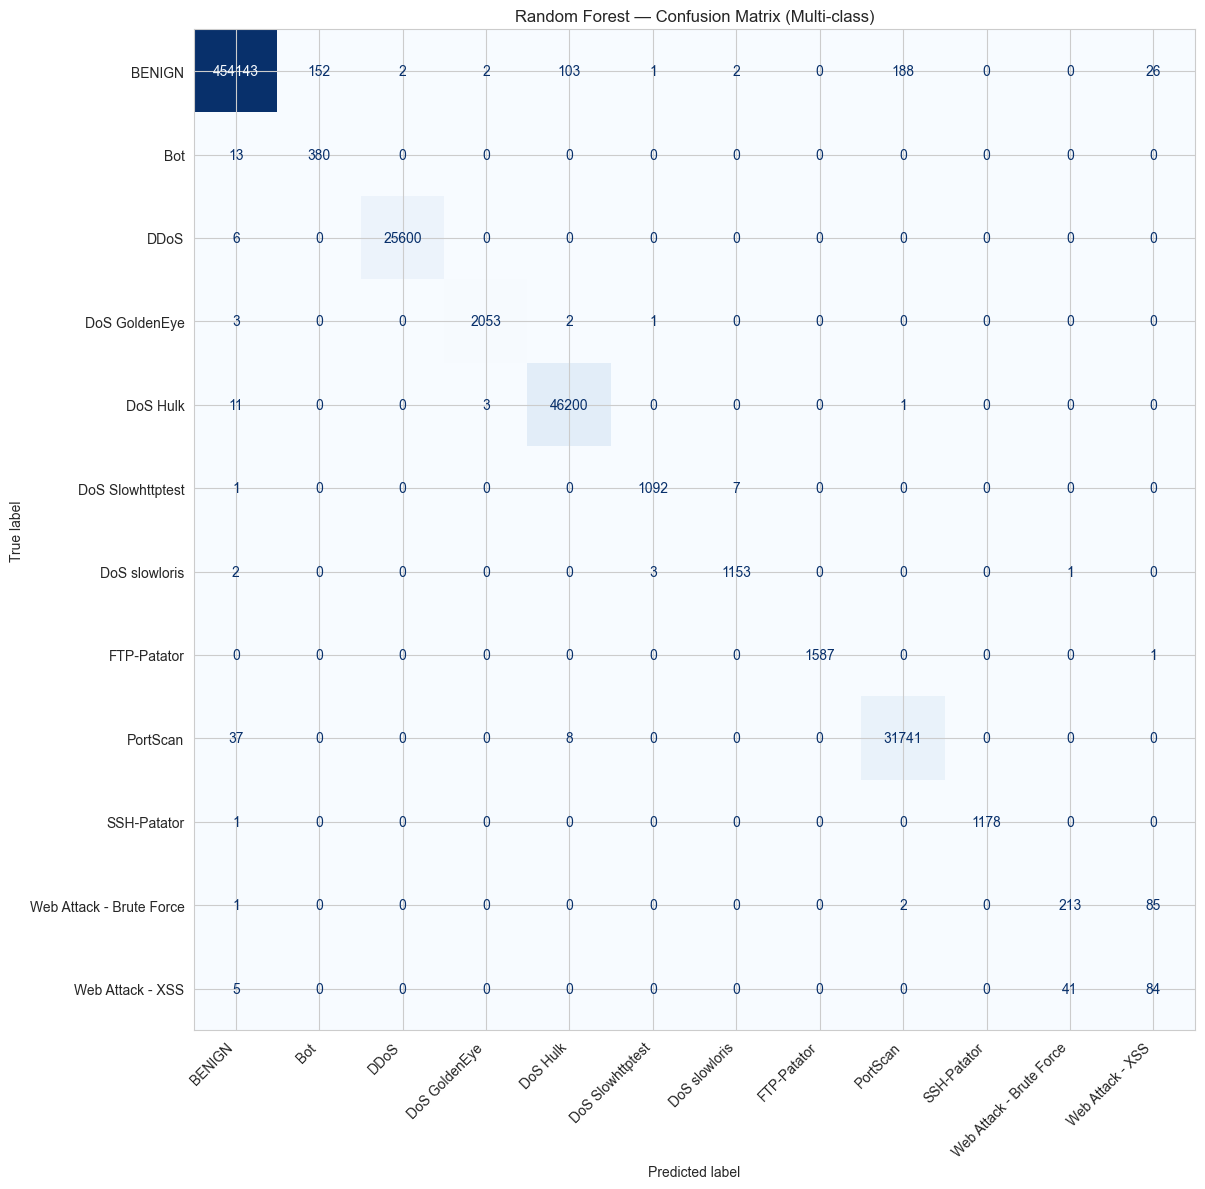

In [ ]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix (Multi-class)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/rf_multiclass_confusion_matrix.png', dpi=150)
plt.show()

Feature Importance for Random Forest

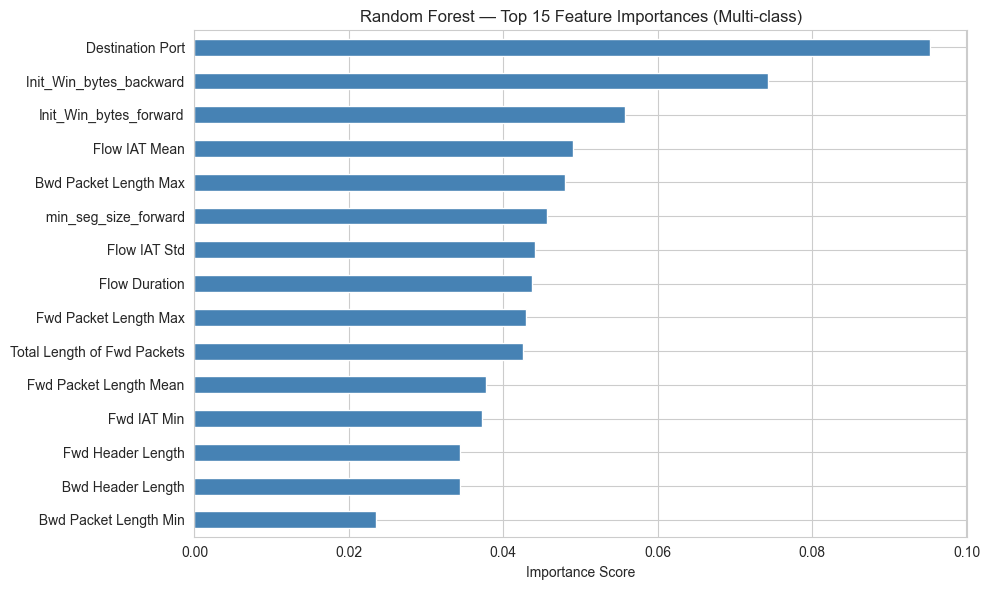

 Destination Port              0.0953
 Init_Win_bytes_backward       0.0743
Init_Win_bytes_forward         0.0557
 Flow IAT Mean                 0.0490
Bwd Packet Length Max          0.0480
 min_seg_size_forward          0.0457
 Flow IAT Std                  0.0441
 Flow Duration                 0.0437
 Fwd Packet Length Max         0.0429
Total Length of Fwd Packets    0.0426
 Fwd Packet Length Mean        0.0377
 Fwd IAT Min                   0.0372
 Fwd Header Length             0.0345
 Bwd Header Length             0.0344
 Bwd Packet Length Min         0.0235
dtype: float64


In [35]:
# Random Forest feature importances    
rf_importances = pd.Series(rf.feature_importances_, index=X_reduced.columns)
rf_top_importances = rf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
rf_top_importances.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Random Forest — Top 15 Feature Importances (Multi-class)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../visuals/rf_multiclass_feature_importance.png', dpi=150)
plt.show()

print(rf_top_importances.round(4))

Logistic Regression Training and Predictions

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1, class_weight=class_weight_dict)
lr.fit(X_train_scaled, y_train)
# Evaluate
y_pred_lr = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr, target_names=class_names))


Training Logistic Regression...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                          precision    recall  f1-score   support

                  BENIGN       1.00      0.79      0.89    454619
                     Bot       0.01      0.99      0.02       393
                    DDoS       0.87      1.00      0.93     25606
           DoS GoldenEye       0.33      0.99      0.50      2059
                DoS Hulk       0.82      1.00      0.90     46215
        DoS Slowhttptest       0.20      0.99      0.33      1100
           DoS slowloris       0.17      0.97      0.29      1159
             FTP-Patator       0.37      1.00      0.54      1588
                PortScan       0.82      1.00      0.90     31786
             SSH-Patator       0.12      0.99      0.22      1179
Web Attack - Brute Force       0.03      0.49      0.06       301
        Web Attack - XSS       0.01      0.82      0.03       130

                accuracy                           0.83    566135
               macro avg       0.40      0.92      0.47    566135
        

In [27]:
# Logistic Regression coefficients
# Shape is (n_classes, n_features) — one row per class
coef_df = pd.DataFrame(
    lr.coef_,
    index=class_names,
    columns=X_reduced.columns
)
print(coef_df.round(4))

                           Destination Port   Flow Duration  \
BENIGN                              58.5758          8.1771   
Bot                                 58.3838         -6.9471   
DDoS                                -7.4655          2.6844   
DoS GoldenEye                      -11.3011         -2.7134   
DoS Hulk                           -21.9381          4.0893   
DoS Slowhttptest                   -26.3036         22.1690   
DoS slowloris                      -17.2568         13.5264   
FTP-Patator                        -23.8449          8.0396   
PortScan                            58.3043        -44.0516   
SSH-Patator                        -43.1644         -2.0028   
Web Attack - Brute Force            -8.1286         -1.6793   
Web Attack - XSS                   -15.8608         -1.2915   

                           Total Fwd Packets  Total Length of Fwd Packets  \
BENIGN                                8.8146                       6.4604   
Bot                       

Confusion Matrix for Logistic Regression

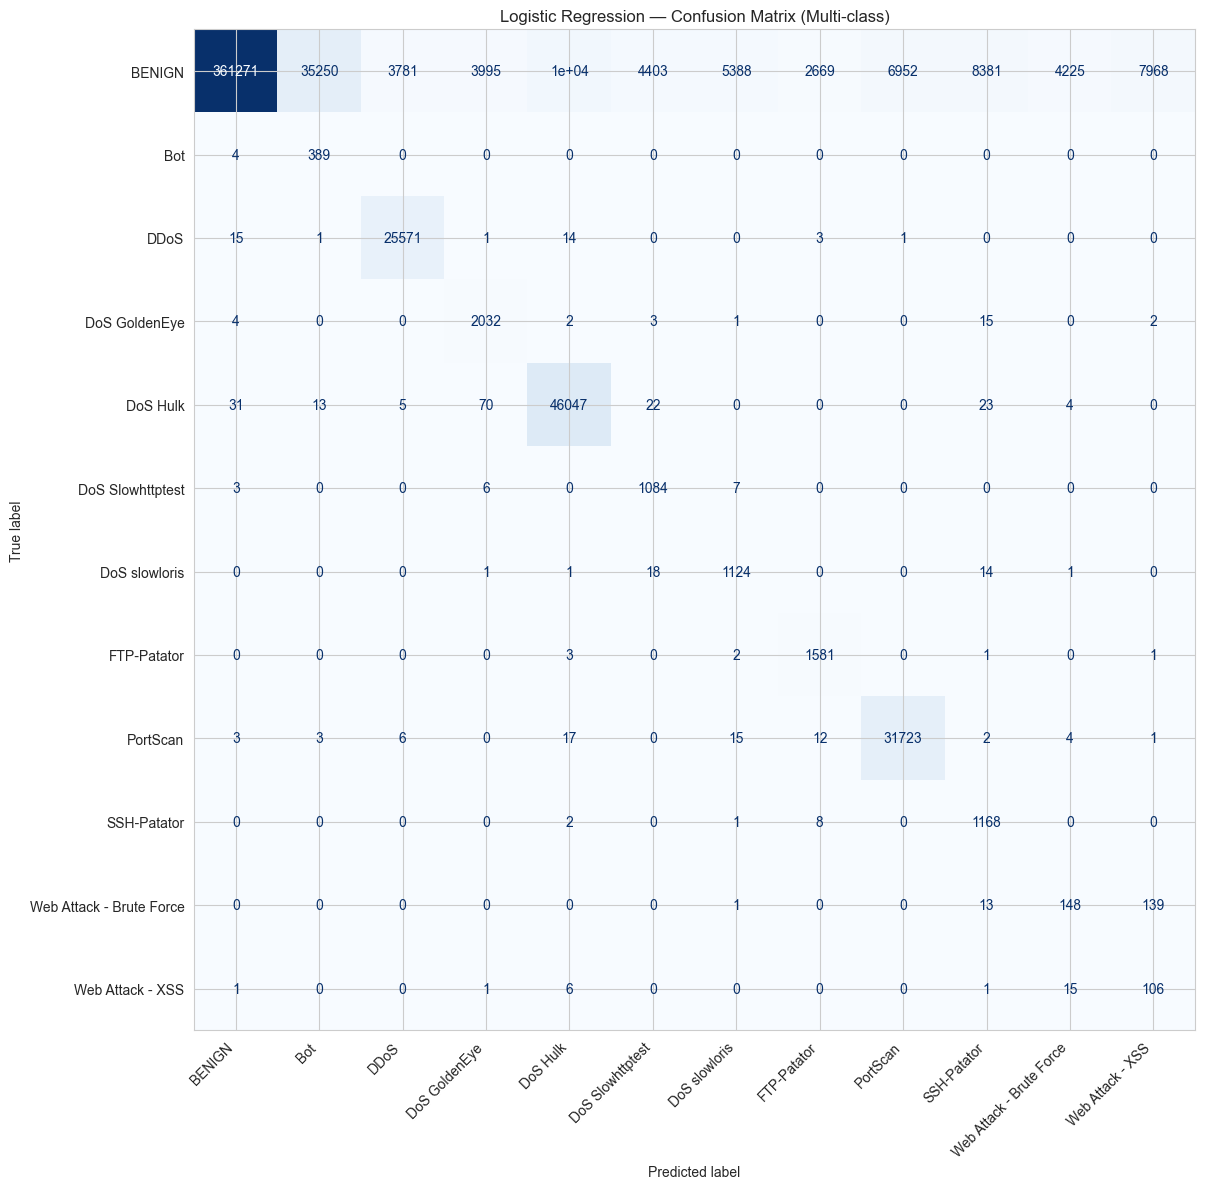

In [22]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix (Multi-class)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/lr_multiclass_confusion_matrix.png', dpi=150)
plt.show()

Decision Tree Training and Predictions

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42, class_weight=class_weight_dict)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print(classification_report(y_test, y_pred_dt, target_names=class_names))

Training Decision Tree...
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    454619
                     Bot       0.86      0.82      0.84       393
                    DDoS       1.00      1.00      1.00     25606
           DoS GoldenEye       1.00      1.00      1.00      2059
                DoS Hulk       1.00      1.00      1.00     46215
        DoS Slowhttptest       0.99      0.98      0.99      1100
           DoS slowloris       0.99      0.99      0.99      1159
             FTP-Patator       1.00      1.00      1.00      1588
                PortScan       0.99      0.99      0.99     31786
             SSH-Patator       1.00      1.00      1.00      1179
Web Attack - Brute Force       0.75      0.81      0.78       301
        Web Attack - XSS       0.46      0.35      0.40       130

                accuracy                           1.00    566135
               macro avg       0.92      0.91   

Decision Tree Confusion Matrix

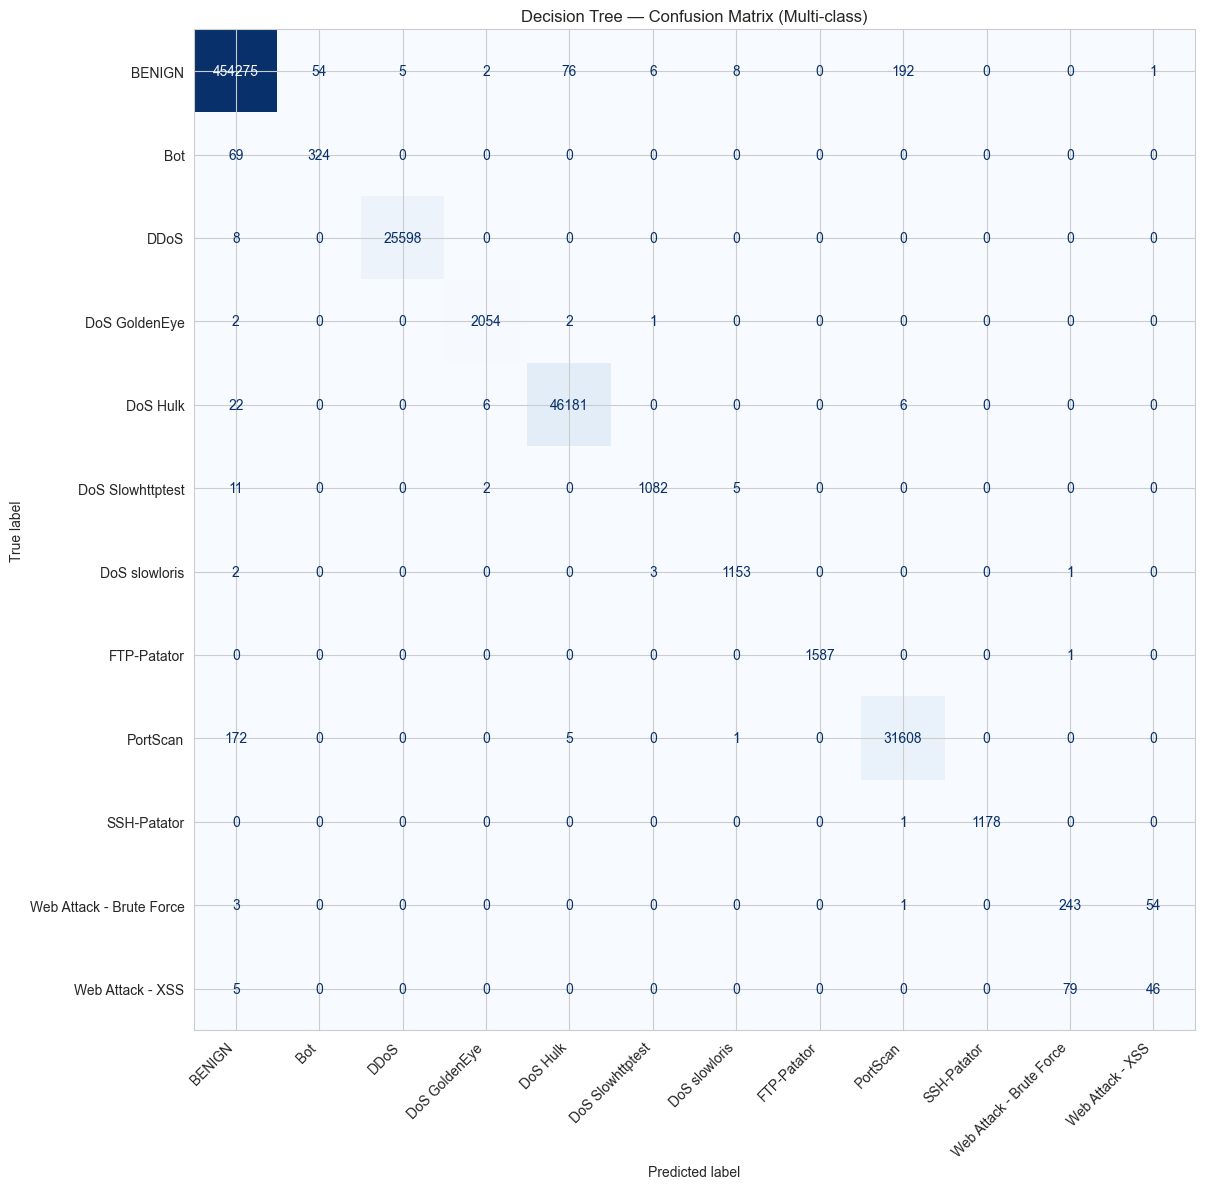

In [25]:
# Confusion Matrix for Decision Tree
cm = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Decision Tree — Confusion Matrix (Multi-class)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/dt_multiclass_confusion_matrix.png', dpi=150)
plt.show()

Feature Importance for Decision Tree

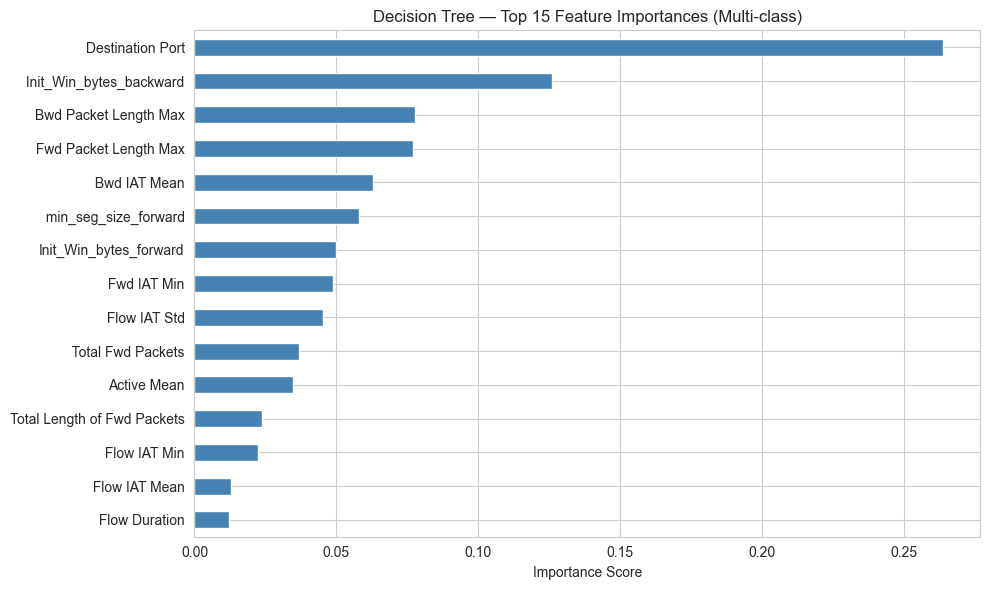

 Destination Port              0.2637
 Init_Win_bytes_backward       0.1261
Bwd Packet Length Max          0.0778
 Fwd Packet Length Max         0.0770
 Bwd IAT Mean                  0.0630
 min_seg_size_forward          0.0581
Init_Win_bytes_forward         0.0498
 Fwd IAT Min                   0.0489
 Flow IAT Std                  0.0454
 Total Fwd Packets             0.0368
Active Mean                    0.0346
Total Length of Fwd Packets    0.0237
 Flow IAT Min                  0.0222
 Flow IAT Mean                 0.0128
 Flow Duration                 0.0121
dtype: float64


In [36]:
dt_importances = pd.Series(dt.feature_importances_, index=X_reduced.columns)
dt_top_importances = dt_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
dt_top_importances.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Decision Tree — Top 15 Feature Importances (Multi-class)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../visuals/dt_multiclass_feature_importance.png', dpi=150)
plt.show()

print(dt_top_importances.round(4))

Full Comparison Table

In [33]:
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

results = pd.DataFrame([
    {'Model': 'Random Forest',      **get_metrics(y_test, y_pred)},
    {'Model': 'Decision Tree',      **get_metrics(y_test, y_pred_dt)},
    {'Model': 'Logistic Regression',**get_metrics(y_test, y_pred_lr)},
]).set_index('Model')

print(results.round(4))
results.to_csv('../data/dashboard/multiclass_model_comparison.csv')

                     Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  \
Model                                                                          
Random Forest          0.9987             0.9129          0.9417      0.9235   
Decision Tree          0.9986             0.9190          0.9127      0.9152   
Logistic Regression    0.8342             0.3964          0.9177      0.4663   

                     F1 (weighted)  
Model                               
Random Forest               0.9988  
Decision Tree               0.9986  
Logistic Regression         0.8820  


Export Data

In [38]:
import os

os.makedirs('../data/dashboard', exist_ok=True)

# Class distribution
df[' Label'].value_counts().reset_index().rename(
    columns={' Label': 'Label', 'count': 'Count'}
).to_csv('../data/dashboard/multiclass_class_distribution.csv', index=False)

# Feature importances — Random Forest
rf_top_importances.reset_index().rename(
    columns={'index': 'Feature', 0: 'Importance'}
).to_csv('../data/dashboard/rf_multiclass_feature_importance.csv', index=False)

# Feature importances — Decision Tree 
dt_top_importances.reset_index().rename(
    columns={'index': 'Feature', 0: 'Importance'}
).to_csv('../data/dashboard/dt_multiclass_feature_importance.csv', index=False)

# Logistic Regression coefficients
coef_df = pd.DataFrame(
    lr.coef_,
    index=class_names,
    columns=X_reduced.columns
)
coef_long = coef_df.T.melt(var_name='Class', value_name='Coefficient', ignore_index=False)
coef_long.index.name = 'Feature'
coef_long = coef_long.reset_index()
coef_long.to_csv('../data/dashboard/lr_coefficients.csv', index=False)

# Per-class RF metrics
from sklearn.metrics import classification_report
report_dict = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T.iloc[:-3]
report_df.to_csv('../data/dashboard/multiclass_per_class_metrics.csv')

# Full predictions of Random Forest
pred_df = X_test.copy()
pred_df['True_Label'] = le.inverse_transform(y_test.values)
pred_df['RF_Prediction'] = le.inverse_transform(y_pred)
pred_df['Correct'] = (pred_df['True_Label'] == pred_df['RF_Prediction']).astype(int)
pred_df.to_csv('../data/dashboard/multiclass_predictions.csv', index=False)

print("All files exported:")
print(os.listdir('../data/dashboard'))

All files exported:
['multiclass_model_comparison.csv', 'multiclass_predictions.csv', 'dt_multiclass_feature_importance.csv', 'rf_multiclass_feature_importance.csv', 'multiclass_per_class_metrics.csv', 'lr_coefficients.csv', 'multiclass_class_distribution.csv']
